In [12]:
import sys
# Add your lenscarf site-packages to the path
sys.path.append('/users/odarwish/lenscarf/lib/python3.12/site-packages')

import numpy as np

import matplotlib.pyplot as plt

sys.path.append('/users/odarwish/abacusutils/')

import jax
from jax import numpy as jnp

from abacusnbody.data.read_abacus import read_asdf

import numpy as np

from abacusnbody.analysis.tsc import tsc_parallel

import matplotlib.pyplot as plt

from abacusnbody.analysis.power_spectrum import calc_power, calc_pk_from_deltak, get_k_mu_edges
from abacusnbody.analysis import power_spectrum as ps

from scipy.fft import rfftn, irfftn

import astropy

from classy import Class

import yaml

from pathlib import Path


import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib.ticker import LogLocator, LogFormatter, AutoMinorLocator
from matplotlib.gridspec import GridSpec
from matplotlib import patheffects
import matplotlib as mpl

# ---- CONFIGURATION ----
# Use golden ratio for figure dimensions
GOLDEN_RATIO = (5**0.5 - 1) / 2
FIG_WIDTH = 5  # inches
FIG_HEIGHT = FIG_WIDTH * GOLDEN_RATIO
DPI = 300

# Check for and configure LaTeX if available (optional but professional)
# Uncomment this if you have LaTeX installed
# plt.rcParams.update({
#     "text.usetex": True,
#     "font.family": "serif",
#     "font.serif": ["Computer Modern Roman"],
# })

# If not using LaTeX, use a clean serif font
# Try to use TeX fonts that are included with matplotlib
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "Times New Roman", "DejaVu Serif"],
    "mathtext.fontset": "cm"  # Use Computer Modern math font
})

# Define a modern, colorblind-friendly palette with higher contrast
# Based on colorblindness-friendly scientific palettes like viridis
# and ones recommended by Nature and Science publications
COLORBLIND_PALETTE = [
    '#0072B2',  # Blue
    '#D55E00',  # Orange
    '#009E73',  # Green
    '#CC79A7',  # Pink
    '#56B4E9',  # Light blue
    '#E69F00',  # Yellow
    '#000000',  # Black
    '#F0E442'   # Light yellow
]

In [3]:
key_selected = "n"

# More descriptive and professionally formatted names
names = {
    "n": r"$\mathcal{D}$",          # Using calligraphic D for density
    "x": r"$\varepsilon$",           # Using proper epsilon symbol
    "s": r"$\mathcal{S}$",           # Calligraphic S
    "t": r"$\mathcal{T}$",           # Calligraphic T
    "g": r"$\mathcal{G}$",           # Calligraphic G
    "x2": r"$10\varepsilon$"         # 10 epsilon
}

estimators_all = ["s", "g", "t", "n", "x", "x2"]
estimators_base = ["s", "g", "t", "x"]

In [4]:
configuration = '../configs/abacus/config_abacus_thy.yaml'

with open(configuration, 'r') as f:
    config = yaml.safe_load(f)

ps_main_directory = config['power_spectrum']['main_directory']
name_config = config['name']
gen_nl_power = np.loadtxt(ps_main_directory+name_config+"/"+config['power_spectrum']['nonlinear'])
gen_power = np.loadtxt(ps_main_directory+name_config+"/"+config['power_spectrum']['linear'])

In [5]:
output_config = config['output']
filename_prefix = output_config['filename_prefix']
filename_prefix = output_config['filename_prefix']
output_dir = Path(output_config['directory'])/config['name']

In [6]:
#ic = load_dens(ic_dir, sim_name, ngrid)
import jax.numpy as jnp
pnlinf = lambda kmag: jnp.interp(kmag, gen_nl_power[:,0], gen_nl_power[:,1])
plinf = lambda kmag: jnp.interp(kmag, gen_power[:,0], gen_power[:,1])

kmin, kmax = config['k_range']['kmin'], config['k_range']['kmax']

In [7]:
output_config = config['output']
filename_prefix = output_config['filename_prefix']
filename_prefix = output_config['filename_prefix']
output_dir = Path(output_config['directory'])/config['name']

nome = "analysisAbacusSummit_base_c000_ph000_z0.500_LRG_ELG_normalization_AB.npy"
nomev = "analysisAbacusSummit_base_c000_ph000_z0.500_LRG_ELG_variance_AB.npy"
nometri = "analysisAbacusSummit_base_c000_ph000_z0.500_LRG_ELG_shot_trispectrum_AB.npy"
nomebis_mixed = "analysisAbacusSummit_base_c000_ph000_z0.500_LRG_ELG_cross_shot_AB.npy"
nomebis = "analysisAbacusSummit_base_c000_ph000_z0.500_LRG_ELG_shot_bispectrum_AB.npy"
#out_normalization_AB = np.load(output_dir / f"{filename_prefix}_normalization_AB.npy", allow_pickle = True).item()

out_normalization_AB = np.load(output_dir / nome, allow_pickle = True).item()
#out_variance_AB = np.load(output_dir / f"{filename_prefix}_variance_AB.npy", allow_pickle = True).item()

analysis_cross_shot_AB = np.load(output_dir / nomebis_mixed, allow_pickle = True).item()
out_variance_AB_other = np.load(output_dir / nomev, allow_pickle = True).item()
out_shot_trispectrum = np.load(output_dir / nometri, allow_pickle = True).item()
out_shot_bispectrum = np.load(output_dir / nomebis, allow_pickle = True).item()


kr_config = config['k_range']
kmin = kr_config['kmin']
kmax = kr_config['kmax']
k_samples = kr_config['k_samples']
k_min_analysis = kr_config['k_min_analysis']
k_max_analysis = kr_config['k_max_analysis']

kmin_max = 2*k_min_analysis
Ks_ = np.linspace(k_min_analysis, kmin_max, 20)
Ks = np.logspace(np.log10(kmin_max), np.log10(k_max_analysis), k_samples)
Ks = np.concatenate([Ks_, Ks])
Ks = np.unique(Ks)
#Ks = np.linspace(k_min_analysis, k_max_analysis, k_samples)

In [8]:
import jax
from jax import numpy as jnp
def symm(f, A, B, **kwargs):
    return (f(A, B, **kwargs)+f(B, A, **kwargs))/2
def asymm(f, A, B, **kwargs):
    return (f(A, B, **kwargs)-f(B, A, **kwargs))/2

def bs2_coev(b10):
  """
  Coevolution value of the bs2 parameter
  """
  return -2./7.*(b10-1)

def b2_fit(b10):
    return 2*(0.412-2.143*b10 + 0.929*b10**2 + 0.008*b10**3)

def br_formula(b1, z = 0.5):
    h = 0.6736
    H0 = h*100
    bias = 6.8*((1+z)*H0)**-1.*(b1-1) #formula 20 from Schmidt 2016
    return bias

def bGX(b10):
    factor = 1421/510
    return br_formula(b10)*factor

def bSX(b10):
    factor = 17/6
    return br_formula(b10)*factor

def bTX(b10):
    factor = 91/30
    return br_formula(b10)*factor


def cg_g(biases_A, biases_B, e):
    return (biases_A[0]+21/17*biases_A[1]+e*biases_A[2])*biases_B[0]

def cg_s(biases_A, biases_B, e):
    return (biases_A[0]+e*biases_A[1])*biases_B[0]

def cg_t(biases_A, biases_B, e):
    return (biases_A[0]+7/2*biases_A[1]+e*biases_A[2])*biases_B[0]

b1A = 1.6
b1B = 1.6
e = 1e-3

b2A, b2B = b2_fit(b1A), b2_fit(b1B)
bGXA, bGXB = bGX(b1A), bGX(b1B)
bSXA, bSXB = bSX(b1A), bSX(b1B)
bs2A, bs2B = bs2_coev(b1A), bs2_coev(b1B)
bTXA, bTXB = bTX(b1A), bTX(b1B)

def get_Cg_biases(e, b1A, b1B, b2A, b2B, bGXA, bGXB, bSXA, bSXB, bs2A, bs2B, bTXA, bTXB, zero_shift = 1.):
    """
    Cg = jnp.array([Cg_g, Cg_ga, Cg_s, Cg_sa, Cg_t, Cg_ta])
    """

    biases_A_G = jnp.array([b1A, b2A, bGXA])
    biases_B_G = jnp.array([b1B, b2B, bGXB])

    biases_A_S = jnp.array([b1A, bSXA])
    biases_B_S = jnp.array([b1B, bSXB])

    biases_A_T = jnp.array([b1A, bs2A, bTXA])
    biases_B_T = jnp.array([b1B, bs2B, bTXB])

    Cg_g = symm(cg_g, biases_A_G, biases_B_G, e = e) #need to change definition of symm and asymm
    Cg_ga = asymm(cg_g, biases_A_G, biases_B_G, e = e)

    Cg_s = symm(cg_s, biases_A_S, biases_B_S, e = e)
    Cg_sa = asymm(cg_s, biases_A_S, biases_B_S, e = e)*zero_shift

    Cg_t = symm(cg_t, biases_A_T, biases_B_T, e = e)
    Cg_ta = asymm(cg_t, biases_A_T, biases_B_T, e = e)

    #Cg = jnp.array([Cg_g, Cg_ga, Cg_s, Cg_sa, Cg_t, Cg_ta])
    Cg = jnp.array([Cg_g, Cg_s, Cg_t])

    return Cg 
    
get_Cg_biases(e, b1A, b1B, b2A, b2B, bGXA, bGXB, bSXA, bSXB, bs2A, bs2B, bTXA, bTXB)
#get_Cg_biases(e, b1A, b1B, b2A, b2B, bGXA, bGXB, bSXA, bSXB, bs2A, bs2B, bTXA, bTXB, zero_shift = 0.)

def get_tot_bias(key):
    N = np.array(out_normalization_AB[(key, key)]**-1.)
    N[N>1e10] = 0
    N = jnp.array(N)
    keys = ["g", "s", "t"]
    jax_out_normalization_AB = np.empty((len(keys), len(Ks)))
    for i, k in enumerate(keys):
        jax_out_normalization_AB[i, :] = out_normalization_AB[(key, k)]
    jax_out_normalization_AB = jnp.array(jax_out_normalization_AB)
    partials = N * jax_out_normalization_AB * cg_values[:, jnp.newaxis]
    bias = jnp.sum(partials, axis=0)
    return jnp.nan_to_num(bias)


In [9]:
analysis_cross_shot_AB = np.load(output_dir / nomebis_mixed, allow_pickle = True).item()
out_variance_AB_other = np.load(output_dir / nomev, allow_pickle = True).item()
out_shot_trispectrum = np.load(output_dir / nometri, allow_pickle = True).item()
out_shot_bispectrum = np.load(output_dir / nomebis, allow_pickle = True).item()

In [10]:
output_dir / nometri

PosixPath('../results/abacus_thy/analysisAbacusSummit_base_c000_ph000_z0.500_LRG_ELG_shot_trispectrum_AB.npy')

## Plotting noise properties

In [11]:
mainkey = "n"
mainkey = "g"
kother = "sa"

key = (mainkey, mainkey)
N = out_normalization_AB[key]**-1.


V = out_variance_AB_other[key]
T = out_shot_trispectrum[key]
Smixed = analysis_cross_shot_AB[key]
S = out_shot_bispectrum[key]

plt.loglog(Ks, (V*N**2))
plt.loglog(Ks, (N), ls = "--")

plt.loglog(Ks, (Smixed*N))
plt.loglog(Ks, (S*N))

plt.loglog(Ks, -(T*N**2), lw = 2)

plt.plot(Ks, plinf(Ks), lw = 2, color = "black")


#key = (mainkey, kother)
#T = out_shot_trispectrum[key]
#plt.loglog(Ks, (T*N**2), lw = 2)

#key = (kother, kother)
#T = out_shot_trispectrum[key]
#plt.loglog(Ks, (T*N**2), lw = 2)

#plt.ylim(1e-7)

KeyError: ('g', 'g')

## Plotting responses

In [ ]:
# ---- FIGURE CREATION ----
# Create figure with golden ratio and higher dpi
fig = plt.figure(figsize=(FIG_WIDTH, FIG_HEIGHT), dpi=DPI, facecolor='white')
# Use GridSpec for more control over plot layout
gs = GridSpec(1, 1, figure=fig, left=0.15, right=0.95, bottom=0.15, top=0.92)
ax = fig.add_subplot(gs[0, 0])

# Professional tick parameters
ax.tick_params(axis='both', which='major', direction='in', length=5, width=0.8, 
               top=True, right=False, labelsize=10)
ax.tick_params(axis='both', which='minor', direction='in', length=3, width=0.6, 
               top=True, right=False)

i = 0
color = COLORBLIND_PALETTE[i % len(COLORBLIND_PALETTE)]


# Set up clean, professional plot styling with pure white background
ax.set_facecolor('white')
for spine in ax.spines.values():
    spine.set_linewidth(0.8)
    spine.set_color('black')

keys = ["g", "s", "t", "ga", "sa", "ta"]
labels = [r"$\mathrm{\mathcal{G}}_{\mathrm{symm}}$", r"$\mathrm{\mathcal{S}}_{\mathrm{symm}}$", r"$\mathrm{\mathcal{T}}_{\mathrm{symm}}$", r"$\mathrm{\mathcal{G}}_{\mathrm{asymm}}$", r"$\mathrm{\mathcal{S}}_{\mathrm{asymm}}$", r"$\mathrm{\mathcal{T}}_{\mathrm{asymm}}$"]

normalized = False

if normalized:
    N = out_normalization_AB[(mainkey, mainkey)]**-1.
else:
    N = 1
    
for i, k in enumerate(keys):
    color_ = COLORBLIND_PALETTE[i%3]
    R = out_normalization_AB[(mainkey, k)]
    ax.loglog(Ks, N*(R), label = labels[i], color = color_, ls = "-" if i < 3 else "--")


R = out_normalization_AB[(kother, kother)]
ax.loglog(Ks, N*(R), label = labels[-2]+labels[-2], color = "black", ls = "-", lw = 1, alpha = 0.5)

    
ax.set_xlabel(r'$K \ \mathrm{[h/Mpc]}$', fontsize=16)

if normalized:
    ax.set_ylabel(r'$N_{\mathcal{D}\mathcal{D}}R_{{\mathcal{D}\beta}}$', fontsize=16)
else:
    ax.set_ylabel(r'$R_{{\mathcal{D}\beta}}$', fontsize=16)


ax.legend(ncol = 2, loc = "upper right")
ax.set_xlim(1e-3, 1e-1)
if normalized:
    ax.set_ylim(1e-5, 3)
else:
    #ax.set_ylim(-1e-7, 1e-7)
    pass

ax.set_yscale('symlog', linthresh = 1e-7)  # Adjust threshold based on your data
fig.savefig(f"/users/odarwish/long-modes/figures/responses.pdf", dpi = 300, bbox_inches='tight')
plt.show()
plt.close()

## Overall bias

['g', 's', 't', 'ga', 'sa', 'ta']


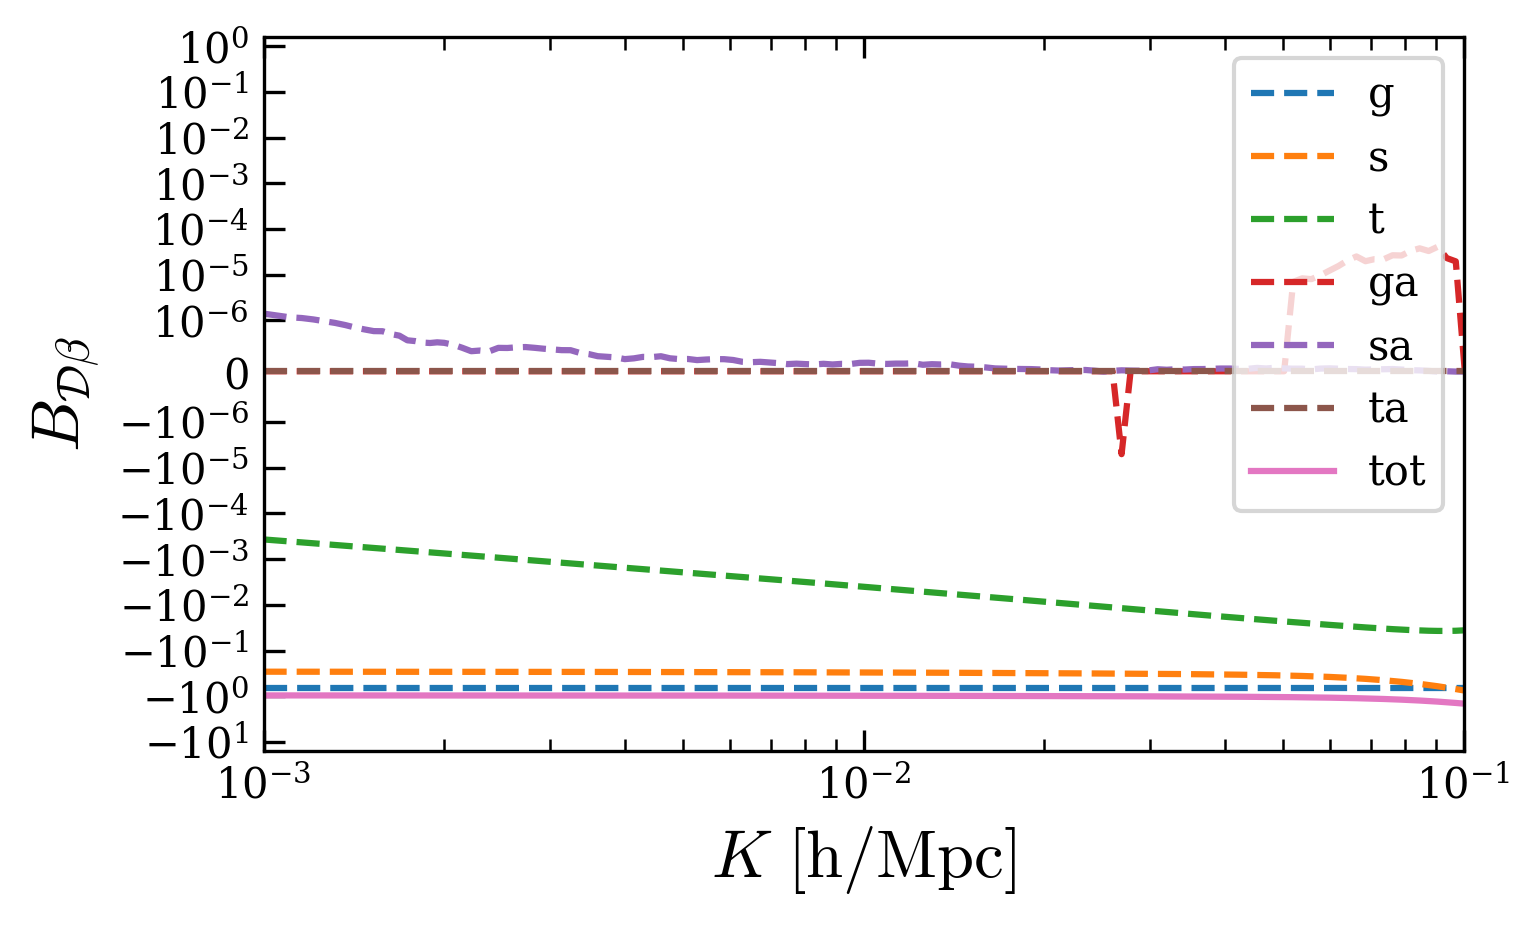

In [49]:
sys.path.append('/users/odarwish/qeep/')
from qeep import biases as qb



# ---- FIGURE CREATION ----
# Create figure with golden ratio and higher dpi
fig = plt.figure(figsize=(FIG_WIDTH, FIG_HEIGHT), dpi=DPI, facecolor='white')
# Use GridSpec for more control over plot layout
gs = GridSpec(1, 1, figure=fig, left=0.15, right=0.95, bottom=0.15, top=0.92)
ax = fig.add_subplot(gs[0, 0])

# Professional tick parameters
ax.tick_params(axis='both', which='major', direction='in', length=5, width=0.8, 
               top=True, right=False, labelsize=10)
ax.tick_params(axis='both', which='minor', direction='in', length=3, width=0.6, 
               top=True, right=False)

i = 0
color = COLORBLIND_PALETTE[i % len(COLORBLIND_PALETTE)]


# Set up clean, professional plot styling with pure white background
ax.set_facecolor('white')
for spine in ax.spines.values():
    spine.set_linewidth(0.8)
    spine.set_color('black')

### SET UP BIASES ### 
b1A = 1.6
b1B = 1.1

e = 1e-2

#############

b1C = b1A

b2A, b2B = qb.b2_fit(b1A), qb.b2_fit(b1B)
bs2A, bs2B = qb.bs2_coev(b1A), qb.bs2_coev(b1B)
bGXA, bGXB, bSXA, bSXB, bTXA, bTXB = qb.bGX(b1A), qb.bGX(b1B), qb.bSX(b1A), qb.bSX(b1B), qb.bTX(b1A), qb.bTX(b1B)
#bGXA, bGXB, bSXA, bSXB, bTXA, bTXB = 1, 1, 1, 1, 1, 1

Cg = qb.get_Cg_biases(e, b1A, b1B, b2A, b2B, bs2A, bs2B, bGXA, bGXB, bSXA, bSXB, bTXA, bTXB, asymm_shift = 1.)


N = out_normalization_AB[(mainkey, mainkey)]**-1.

bias = 0.
print(keys)
for i, k in enumerate(keys):
    color_ = COLORBLIND_PALETTE[i%3]
    R = out_normalization_AB[(mainkey, k)]
    partial = N*(R)*Cg[i]
    bias += partial
    ax.plot(Ks, (partial), label = k, ls = "--")
ax.loglog(Ks, (bias), label = "tot")
ax.legend()
ax.set_yscale('symlog', linthresh = 1e-6)
ax.set_xlim(1e-3, 1e-1)

ax.set_xlabel(r'$K \ \mathrm{[h/Mpc]}$', fontsize=16)

if normalized:
    ax.set_ylabel(r'$N_{\mathcal{D}\mathcal{D}}R_{{\mathcal{D}\beta}}$', fontsize=16)
else:
    ax.set_ylabel(r'$B_{{\mathcal{D}\beta}}$', fontsize=16)

## Plotting overall power spectrum

In [59]:
from qeep import biases


def plinear():
    return pnlinf(Ks)

def E_bottaro():
    z_eq = 3400
    a_eq = 1/(1+z_eq)
    a = 1.
    fchi = 1.
    factor = jnp.log(a/a_eq)-181/90
    factor *= fchi
    factor *= 6/5
    return factor

def G(epsilon, one = 1):
    E = E_bottaro()
    return 1+epsilon*E*one


def power_spectrum(v, nshot, growth_eps = 1.):
    """
    External power spectrum
    """
    eps, b1X = v
    return  b1X**2*plinear()*G(eps, growth_eps)**2 + nshot

def get_CG(v, asymm_shift = 1., only_asymm_shift = 0.):  
    """
    Effective biases.
    """
    e, b1A, b1B, b2A, b2B, bs2A, bs2B, bGXA, bGXB, bSXA, bSXB, bTXA, bTXB = v
    Cg = biases.get_Cg_biases(e, b1A, b1B, b2A, b2B, bs2A, bs2B, bGXA, bGXB, bSXA, bSXB, bTXA, bTXB, asymm_shift = asymm_shift, only_asymm_shift = only_asymm_shift)
    return Cg


def get_tot_bias_Cg(normalization, Cg, jax_out_normalization_AB): #, keys = ["g", "s", "t", "ga", "sa", "ta"]):
    partials = normalization * jax_out_normalization_AB * Cg[:, jnp.newaxis] #if (len(keys) > 1) else normalization * jax_out_normalization_AB * Cg
    bias = jnp.sum(partials, axis=0)

    #bias = normalization * jax_out_normalization_AB[5, :] * Cg[5] #if (len(keys) > 1) else normalization * jax_out_normalization_AB * Cg
    return jnp.nan_to_num(bias)

def get_tot_bias(v, normalization, jax_out_normalization_AB, asymm_shift = 1, only_asymm_shift = 0.):
    Cg = get_CG(v, asymm_shift = asymm_shift, only_asymm_shift = only_asymm_shift)
    return get_tot_bias_Cg(normalization, Cg, jax_out_normalization_AB)

def cross_spectrum(v, normalization, jax_out_normalization_AB, bisp_noise, asymm_shift = 1, only_asymm_shift = 0., growth_eps = 1.):
    """
    bisp_noise, bispectrum shot noise
    growth_eps, include growth term epsilon or not
    """
    bias = get_tot_bias(v, normalization, jax_out_normalization_AB, asymm_shift = asymm_shift, only_asymm_shift = only_asymm_shift)
    signal = bias*plinear()*G(v[0], growth_eps)**3
    return signal + bisp_noise

def auto_spectrum(v, normalization, jax_out_normalization_AB, var_noise, tris_noise, signal = 1., asymm_shift = 1, only_asymm_shift = 0, growth_eps = 1.):
    bias = get_tot_bias(v, normalization, jax_out_normalization_AB, asymm_shift = asymm_shift, only_asymm_shift = only_asymm_shift)
    signal = bias**2*plinear()*signal*G(v[0], growth_eps)**4
    return signal + var_noise + tris_noise

In [60]:
from qeep import qeresults as qres

In [61]:
QR = qres.QEResults(config)
out_normalization_AB = QR.get_out_normalization_AB()
jax_out_normalization_AB = qres.get_normalization_array("n", ["g", "s", "t", "ga", "sa", "ta"], Ks, out_normalization_AB)

In [64]:
def get_functions(key, QR, shot_noise = 1., variance_factor = 1., bispectrum_factor = 1., trispectrum_factor = 1., asymm_shift = 1., only_asymm_shift = 0., growth_eps = 0., vfid = None, fiducial_auto = False, fiducial_cross = False, fiducial_power = False):
    
    #e, b1A, b1B, b2A, b2B, bs2A, bs2B, bGXA, bGXB, bSXA, bSXB, bTXA, bTXB = v

    variance_noise = QR.get_get_variance()(key)*variance_factor
    bispectrum_noise = QR.get_get_bispectrum()(key)*bispectrum_factor
    trispectrum_noise = QR.get_get_trispectrum()(key)*trispectrum_factor
    normalization = QR.get_get_norm()(key)
    out_normalization_AB = QR.get_out_normalization_AB()
    
    keys = ["g", "s", "t", "ga", "sa", "ta"]
    jax_out_normalization_AB = qres.get_normalization_array(key, keys, Ks, out_normalization_AB)
    
    CAR = lambda v: cross_spectrum(v if not fiducial_cross else vfid, normalization, jax_out_normalization_AB, bispectrum_noise, asymm_shift = asymm_shift, growth_eps = growth_eps, only_asymm_shift = only_asymm_shift) #gets cross-spectrum
    
    CRR = lambda v: auto_spectrum(v if not fiducial_auto else vfid, normalization, jax_out_normalization_AB, variance_noise, trispectrum_noise, asymm_shift = asymm_shift, growth_eps = growth_eps, only_asymm_shift = only_asymm_shift) #gets reconstruction auto-spectrum
    
    CAA = lambda v: power_spectrum(v[:2] if not fiducial_power else vfid[:2], shot_noise, growth_eps = growth_eps) #gets galaxy auto-spectrum

    #CAA = lambda v: power_spectrum(v[:2] if not fiducial_power else vA[:2], shot_noise, growth_eps = growth_eps) #gets galaxy auto-spectrum

    return CAA, CAR, CRR


def get_v(vA):
    e, b1A, b2A, bs2A, bGXA, bGXB, bSXA, bSXB, bTXA, bTXB = vA
    b1B, b2B, bs2B = b1A, b2A, bs2A
    v = jnp.array([e, b1A, b1B, b2A, b2B, bs2A, bs2B, bGXA, bGXB, bSXA, bSXB, bTXA, bTXB])
    return v

def get_functions_vA_only(CAA, CAR, CRR):
        
    def CAA_(vA):
        return CAA(get_v(vA))

    def CAR_(vA):
            return CAR(get_v(vA))

    def CRR_(vA):
            return CRR(get_v(vA))

    return CAA_, CAR_, CRR_


def get_cov(CAAf, CARf, CRRf):
    @jax.jit
    def covariance_full(K_array, v):

        n_probes = 2

        C = jnp.zeros((len(K_array), n_probes, n_probes))
        
        CAR = CARf(v)
        
        C = C.at[:, 0, 0].set(CRRf(v))
        C = C.at[:, 0, 1].set(CAR)
        C = C.at[:, 1, 0].set(CAR)
        C = C.at[:, 1, 1].set(CAAf(v))
        
        return C
    
    return covariance_full

def get_Ofuncs(CAAf, CARf, CRRf):
    Ofunc = lambda K_arr, v: CARf(v)
    variance_func = lambda K_arr, v: CAAf(v)*CRRf(v)+CARf(v)**2
    return Ofunc, variance_func

In [63]:
vA = jnp.array([e, b1A, b2A, bs2A, bGXA, bGXB, bSXA, bSXB, bTXA, bTXB])

mainkey = mainkey
QR = QR

shot_noise = 0.
variance_factor = 0.
bispectrum_factor = 0.
trispectrum_factor = 0.
asymm_shift = 1.
only_asymm_shift = 0.
growth_eps = 0.

vfid = None
fiducial_auto = False
fiducial_cross = False
fiducial_power = False

CAA, CAR, CRR = get_functions_vA_only(*get_functions(
    mainkey,
    QR,
    shot_noise=shot_noise,
    variance_factor=variance_factor,
    bispectrum_factor=bispectrum_factor,
    trispectrum_factor=trispectrum_factor,
    asymm_shift=asymm_shift,
    only_asymm_shift=only_asymm_shift,
    growth_eps=growth_eps,
    vfid=vfid,
    fiducial_auto=fiducial_auto,
    fiducial_cross=fiducial_cross,
    fiducial_power=fiducial_power
))

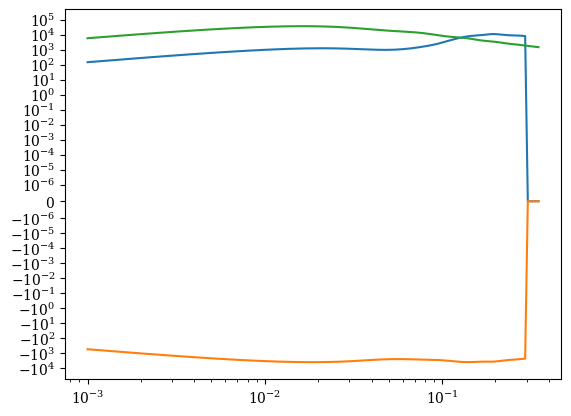

In [65]:
plt.loglog(Ks, CRR(vA))
plt.loglog(Ks, (CAR(vA)))
plt.loglog(Ks, CAA(vA))
plt.yscale('symlog', linthresh = 1e-6)

In [66]:
variance_noise = QR.get_get_variance()(mainkey)*variance_factor
bispectrum_noise = QR.get_get_bispectrum()(mainkey)*bispectrum_factor
trispectrum_noise = QR.get_get_trispectrum()(mainkey)*trispectrum_factor
normalization = QR.get_get_norm()(mainkey)
out_normalization_AB = QR.get_out_normalization_AB()
keys = ["g", "s", "t", "ga", "sa", "ta"]
jax_out_normalization_AB = qres.get_normalization_array(mainkey, keys, Ks, out_normalization_AB)

KeyError: ('g', 'g')

## Forecasts

<>:26: SyntaxWarning: invalid escape sequence '\e'
<>:26: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_69398/2020252145.py:26: SyntaxWarning: invalid escape sequence '\e'
  labels = ["$\epsilon$", "$b_1$", "$b_2$"]
/tmp/ipykernel_69398/2020252145.py:26: SyntaxWarning: invalid escape sequence '\e'
  labels = ["$\epsilon$", "$b_1$", "$b_2$"]


KeyError: ('g', 'g')

<Figure size 1500x600 with 0 Axes>

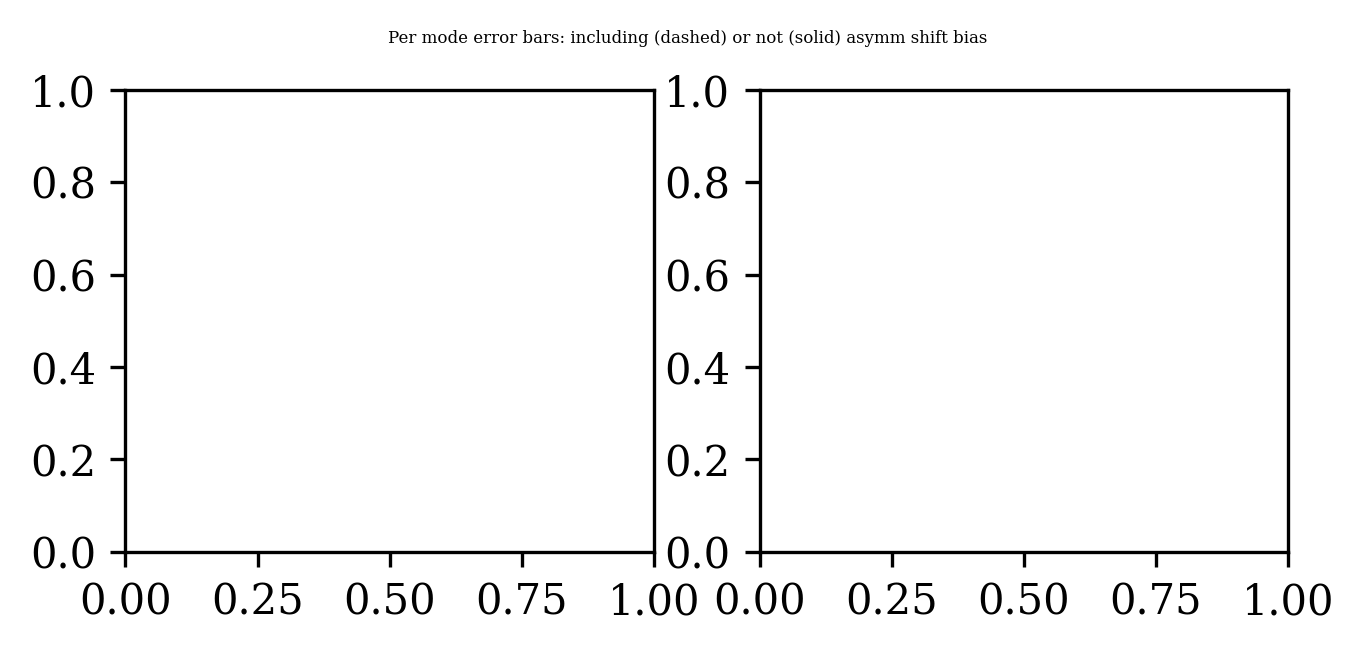

In [67]:
from qeep import fisher

vA = jnp.array([0*e, b1A, b2A, bs2A, bGXA, bGXB, bSXA, bSXB, bTXA, bTXB]) #fiducial point

mainkey = mainkey
QR = QR

shot_noise = 0.
variance_factor = 0.
bispectrum_factor = 0.
trispectrum_factor = 0.
asymm_shift = 1.
only_asymm_shift = 0.
growth_eps = 0.

vfid = None
fiducial_auto = False
fiducial_cross = False
fiducial_power = False


fig = plt.figure(figsize=(5, 2), dpi=DPI, facecolor='white')
indices = [0, 1]

fig, axs = plt.subplots(1, len(indices), figsize=(5, 2), dpi=DPI, facecolor='white')
labels = ["$\epsilon$", "$b_1$", "$b_2$"]

fig.suptitle("Per mode error bars: including (dashed) or not (solid) asymm shift bias", fontsize = 4)

for asymm_shift in [0, 1]:
    
    CAA, CAR, CRR = get_functions_vA_only(*get_functions(
        mainkey,
        QR,
        shot_noise=shot_noise,
        variance_factor=variance_factor,
        bispectrum_factor=bispectrum_factor,
        trispectrum_factor=trispectrum_factor,
        asymm_shift=asymm_shift,
        only_asymm_shift=only_asymm_shift,
        growth_eps=growth_eps,
        vfid=vfid,
        fiducial_auto=fiducial_auto,
        fiducial_cross=fiducial_cross,
        fiducial_power=fiducial_power
    ))
    
    cov = get_cov(CAA, CAR, CRR)
    O, Ovar = get_Ofuncs(CAA, CAR, CRR)
    
    F_single = fisher.fisher_per_mode_single(vA, Ks, O, Ovar)
    F_single = jnp.nan_to_num(F_single)
    
    F = fisher.fisher_per_mode(vA, Ks, cov)


    for i, index in enumerate(indices):
        ax = axs[i]
        ax.set_title(labels[i])
        ax.loglog(Ks, F[:, index, index]**-0.5, label = "Joint" if asymm_shift == 0 else None, color = "black", ls = "-" if asymm_shift == 0 else "--")
        ax.loglog(Ks, F_single[:, index, index]**-0.5, color = "red", label = "Cross-only" if asymm_shift == 0 else None, ls = "-" if asymm_shift == 0 else "--")
        ax.set_xlabel("$K$")
        ax.set_xlim(1e-3, 1e-1)
        #ax.set_ylim(1e-6)
        ax.axvspan(QR.kmin, QR.kmax, alpha=0.3, color = 'black')
        ax.legend()
#fig.tight_layout()

<>:22: SyntaxWarning: invalid escape sequence '\e'
<>:22: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_69398/2314628529.py:22: SyntaxWarning: invalid escape sequence '\e'
  labels = ["$\epsilon$", "$b_1$", "$b_2$"]


<Figure size 1500x600 with 0 Axes>

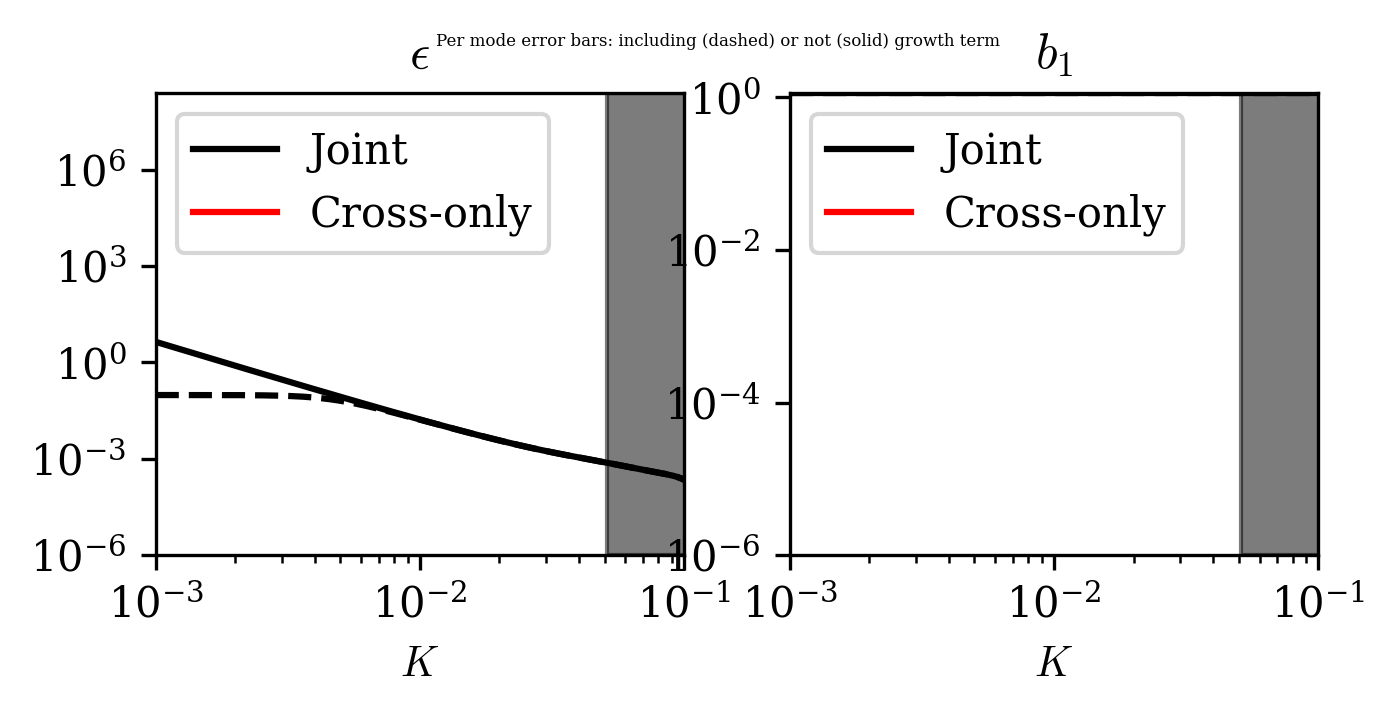

In [45]:
vA = jnp.array([0*e, b1A, b2A, bs2A, bGXA, bGXB, bSXA, bSXB, bTXA, bTXB]) #fiducial point

mainkey = mainkey
QR = QR

shot_noise = 0.
variance_factor = 0.
bispectrum_factor = 0.
trispectrum_factor = 0.
asymm_shift = 1.
only_asymm_shift = 0.
growth_eps = 0.

vfid = None
fiducial_auto = False
fiducial_cross = False
fiducial_power = False


fig = plt.figure(figsize=(5, 2), dpi=DPI, facecolor='white')
indices = [0, 1]
labels = ["$\epsilon$", "$b_1$", "$b_2$"]

fig, axs = plt.subplots(1, len(indices), figsize=(5, 2), dpi=DPI, facecolor='white')
fig.suptitle("Per mode error bars: including (dashed) or not (solid) growth term", fontsize = 4)
for growth_eps in [0, 1]:
    
    CAA, CAR, CRR = get_functions_vA_only(*get_functions(
        mainkey,
        QR,
        shot_noise=shot_noise,
        variance_factor=variance_factor,
        bispectrum_factor=bispectrum_factor,
        trispectrum_factor=trispectrum_factor,
        asymm_shift=asymm_shift,
        only_asymm_shift=only_asymm_shift,
        growth_eps=growth_eps,
        vfid=vfid,
        fiducial_auto=fiducial_auto,
        fiducial_cross=fiducial_cross,
        fiducial_power=fiducial_power
    ))
    
    cov = get_cov(CAA, CAR, CRR)
    O, Ovar = get_Ofuncs(CAA, CAR, CRR)
    
    F_single = fisher.fisher_per_mode_single(vA, Ks, O, Ovar)
    F_single = jnp.nan_to_num(F_single)
    
    F = fisher.fisher_per_mode(vA, Ks, cov)


    for i, index in enumerate(indices):
        ax = axs[i]
        ax.set_title(labels[i])
        ax.loglog(Ks, F[:, index, index]**-0.5, label = "Joint" if growth_eps == 0 else None, color = "black", ls = "-" if growth_eps == 0 else "--")
        ax.loglog(Ks, F_single[:, index, index]**-0.5, color = "red", label = "Cross-only" if growth_eps == 0 else None, ls = "-" if growth_eps == 0 else "--")
        ax.set_xlabel("$K$")
        ax.set_xlim(1e-3, 1e-1)
        ax.set_ylim(1e-6)
        ax.axvspan(QR.kmin, QR.kmax, alpha=0.3, color = 'black')
        ax.legend()